# Multi-Objective Optimization on MOOT Datasets Using Sampled Data

**Goal**: Test whether training a model on a small sampled subset of data can predict near-optimal Pareto-front solutions on the full dataset.

**Workflow**:
1. Load MOOT datasets (column convention: `Name+` = maximize, `Name-` = minimize, `NameX` = ignore, plain = feature)
2. Sample a small % of rows using multiple sampling strategies
3. Train a multi-output regression model on sampled rows
4. Predict objective values for all remaining (unseen) rows
5. Compute predicted Pareto front from predictions
6. Compare against true Pareto front from actual data
7. Repeat 20 times per configuration for statistical reliability

**Sampling Strategies**: Random, Stratified, Clustering (K-Means), Diversity-based (MaxMin), Latin Hypercube (LHS), Sobol Quasi-Random, Active Learning (uncertainty-based)

**Metrics**: Pareto Recall, Pareto Precision, IGD (Inverted Generational Distance), Hypervolume Difference

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from itertools import product

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

from scipy.stats import qmc  # Latin Hypercube & Sobol
from scipy.spatial.distance import cdist

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)

print("All libraries loaded successfully.")

All libraries loaded successfully.


## Section 1: Dataset Loading & Parsing

MOOT column naming convention:
- `ColumnName+` → objective to **maximize**
- `ColumnName-` → objective to **minimize**
- `ColumnNameX` → **ignore** (identifier/metadata)
- Plain name → **feature** (independent variable / decision variable)

We select 6 small-to-medium datasets for initial experiments.

In [2]:
MOOT_ROOT = Path("moot/optimize")

# Selected datasets: mix of domains, sizes, and objective counts
DATASET_PATHS = {
    "auto93":       MOOT_ROOT / "misc" / "auto93.csv",           # 398 rows, 2 obj
    "pom3d":        MOOT_ROOT / "process" / "pom3d.csv",         # 500 rows, 3 obj
    "SS-A":         MOOT_ROOT / "config" / "SS-A.csv",           # 1343 rows, 2 obj
    "SS-B":         MOOT_ROOT / "config" / "SS-B.csv",           # 206 rows, 2 obj
    "Wine_quality": MOOT_ROOT / "misc" / "Wine_quality.csv",     # 1599 rows, 2 obj
    "coc1000":      MOOT_ROOT / "process" / "coc1000.csv",       # 1000 rows, 5 obj
}


def parse_moot_csv(filepath):
    """Parse a MOOT CSV file and separate features, objectives, and metadata.
    
    Returns:
        df: full DataFrame
        feature_cols: list of feature column names (plain names)
        obj_cols: list of objective column names (with +/- suffix)
        obj_directions: dict mapping obj_col -> 'max' or 'min'
        ignore_cols: list of columns ending with X (to ignore)
    """
    df = pd.read_csv(filepath)
    df.columns = [c.strip() for c in df.columns]
    
    feature_cols = []
    obj_cols = []
    obj_directions = {}
    ignore_cols = []
    
    for col in df.columns:
        if col.endswith('+'):
            obj_cols.append(col)
            obj_directions[col] = 'max'
        elif col.endswith('-'):
            obj_cols.append(col)
            obj_directions[col] = 'min'
        elif col.endswith('X'):
            ignore_cols.append(col)
        else:
            feature_cols.append(col)
    
    return df, feature_cols, obj_cols, obj_directions, ignore_cols


def encode_features(df, feature_cols):
    """Encode categorical features as numeric. Returns encoded DataFrame and encoders."""
    df_encoded = df.copy()
    encoders = {}
    for col in feature_cols:
        if df_encoded[col].dtype == 'object':
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            encoders[col] = le
    return df_encoded, encoders


# Load all datasets
datasets = {}
for name, path in DATASET_PATHS.items():
    df, feat_cols, obj_cols, obj_dirs, ignore_cols = parse_moot_csv(path)
    df_enc, encoders = encode_features(df, feat_cols)
    datasets[name] = {
        'df': df_enc,
        'feature_cols': feat_cols,
        'obj_cols': obj_cols,
        'obj_directions': obj_dirs,
        'ignore_cols': ignore_cols,
    }
    print(f"{name:15s} | rows={len(df):5d} | features={len(feat_cols):2d} | "
          f"objectives={len(obj_cols)} ({', '.join(obj_cols)})")

print(f"\nLoaded {len(datasets)} datasets.")

auto93          | rows=  398 | features= 4 | objectives=3 (Lbs-, Acc+, Mpg+)
pom3d           | rows=  500 | features= 9 | objectives=3 (Cost-, Score-, Idle-)
SS-A            | rows= 1343 | features= 3 | objectives=2 (Throughput+, Latency-)
SS-B            | rows=  206 | features= 3 | objectives=2 (A-, B-)
Wine_quality    | rows= 1599 | features=10 | objectives=2 (Alcohol-, Quality+)
coc1000         | rows= 1000 | features=20 | objectives=5 (LOC+, AEXP-, PLEx-, RISK-, EFFORT-)

Loaded 6 datasets.


## Section 2: Pareto Front Computation

A solution **dominates** another if it is at least as good in all objectives and strictly better in at least one. The **Pareto front** is the set of non-dominated solutions.

In [3]:
def normalize_objectives(obj_values, obj_directions, obj_cols):
    """Normalize objective values to [0,1] and flip signs so that all objectives become 'minimize'.
    
    After normalization, lower is better for all objectives.
    """
    normed = obj_values.copy().astype(float)
    for col in obj_cols:
        col_min = normed[col].min()
        col_max = normed[col].max()
        if col_max - col_min > 1e-12:
            normed[col] = (normed[col] - col_min) / (col_max - col_min)
        else:
            normed[col] = 0.0
        # Flip maximization objectives so lower = better
        if obj_directions[col] == 'max':
            normed[col] = 1.0 - normed[col]
    return normed


def is_dominated(row_a, row_b):
    """Check if row_a is dominated by row_b (all objectives minimized after normalization).
    row_b dominates row_a if row_b <= row_a in all objectives and row_b < row_a in at least one.
    """
    return np.all(row_b <= row_a) and np.any(row_b < row_a)


def compute_pareto_front(obj_values_normed):
    """Compute indices of Pareto-optimal rows (non-dominated).
    
    Args:
        obj_values_normed: numpy array of shape (n, m) where all objectives are to be minimized.
    Returns:
        List of indices that form the Pareto front.
    """
    n = len(obj_values_normed)
    is_pareto = np.ones(n, dtype=bool)
    
    for i in range(n):
        if not is_pareto[i]:
            continue
        for j in range(n):
            if i == j or not is_pareto[j]:
                continue
            if is_dominated(obj_values_normed[i], obj_values_normed[j]):
                is_pareto[i] = False
                break
    
    return np.where(is_pareto)[0]


# Compute true Pareto fronts for all datasets
true_pareto_fronts = {}
for name, data in datasets.items():
    obj_vals = data['df'][data['obj_cols']]
    obj_normed = normalize_objectives(obj_vals, data['obj_directions'], data['obj_cols'])
    pf_indices = compute_pareto_front(obj_normed.values)
    true_pareto_fronts[name] = set(pf_indices)
    print(f"{name:15s} | Pareto front size: {len(pf_indices):4d} / {len(data['df'])} "
          f"({100*len(pf_indices)/len(data['df']):.1f}%)")

print("\nTrue Pareto fronts computed for all datasets.")

auto93          | Pareto front size:   13 / 398 (3.3%)
pom3d           | Pareto front size:    7 / 500 (1.4%)
SS-A            | Pareto front size:    3 / 1343 (0.2%)
SS-B            | Pareto front size:    2 / 206 (1.0%)
Wine_quality    | Pareto front size:    4 / 1599 (0.3%)
coc1000         | Pareto front size:  144 / 1000 (14.4%)

True Pareto fronts computed for all datasets.


## Section 3: Sampling Strategies

We implement 7 sampling strategies:

| Strategy | Description |
|---|---|
| **Random** | Uniform random sampling. Simple baseline. |
| **Stratified** | Stratify by binned objective values, sample proportionally from each stratum. |
| **Clustering (K-Means)** | Cluster feature space, pick representative from each cluster. |
| **Diversity (MaxMin)** | Iteratively pick the point farthest from already-selected points. |
| **Latin Hypercube (LHS)** | Space-filling design that ensures each feature dimension is evenly covered. |
| **Sobol (Quasi-Random)** | Low-discrepancy sequence for better space coverage than random. |
| **Active Learning (Uncertainty)** | Start with small random seed, iteratively pick points with highest model uncertainty. |

In [4]:
def sample_random(X, n_samples, rng):
    """Simple random sampling without replacement."""
    indices = rng.choice(len(X), size=n_samples, replace=False)
    return np.sort(indices)


def sample_stratified(X, y_obj, n_samples, rng):
    """Stratified sampling: bin objective space, sample proportionally from each bin."""
    # Create strata by binning the first objective into ~sqrt(n_samples) bins
    n_bins = max(2, int(np.sqrt(n_samples)))
    # Use the first objective for stratification
    y_first = y_obj[:, 0]
    bin_edges = np.percentile(y_first, np.linspace(0, 100, n_bins + 1))
    bin_labels = np.digitize(y_first, bin_edges[:-1]) - 1
    bin_labels = np.clip(bin_labels, 0, n_bins - 1)
    
    unique_bins = np.unique(bin_labels)
    selected = []
    samples_per_bin = max(1, n_samples // len(unique_bins))
    
    for b in unique_bins:
        bin_indices = np.where(bin_labels == b)[0]
        n_take = min(samples_per_bin, len(bin_indices))
        chosen = rng.choice(bin_indices, size=n_take, replace=False)
        selected.extend(chosen)
    
    # If we need more, fill randomly from remaining
    selected = list(set(selected))
    if len(selected) < n_samples:
        remaining = list(set(range(len(X))) - set(selected))
        extra = rng.choice(remaining, size=min(n_samples - len(selected), len(remaining)), replace=False)
        selected.extend(extra)
    
    return np.sort(np.array(selected[:n_samples]))


def sample_clustering(X, n_samples, rng):
    """K-Means clustering: cluster into n_samples groups, pick closest to centroid."""
    n_clusters = min(n_samples, len(X))
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    kmeans = KMeans(n_clusters=n_clusters, random_state=rng.integers(0, 10000), n_init=5)
    kmeans.fit(X_scaled)
    
    selected = []
    for c in range(n_clusters):
        cluster_indices = np.where(kmeans.labels_ == c)[0]
        if len(cluster_indices) == 0:
            continue
        # Pick the point closest to cluster centroid
        dists = cdist(X_scaled[cluster_indices], [kmeans.cluster_centers_[c]])
        best = cluster_indices[np.argmin(dists)]
        selected.append(best)
    
    # If we need more (due to empty clusters), fill randomly
    selected = list(set(selected))
    if len(selected) < n_samples:
        remaining = list(set(range(len(X))) - set(selected))
        extra = rng.choice(remaining, size=min(n_samples - len(selected), len(remaining)), replace=False)
        selected.extend(extra)
    
    return np.sort(np.array(selected[:n_samples]))


def sample_diversity_maxmin(X, n_samples, rng):
    """MaxMin diversity sampling: iteratively pick the point farthest from selected set."""
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    n = len(X)
    
    # Start with a random point
    selected = [rng.integers(0, n)]
    
    # Distance from each point to its nearest selected point
    min_dists = cdist(X_scaled, X_scaled[selected]).flatten()
    
    for _ in range(n_samples - 1):
        # Pick point with largest minimum distance to selected set
        candidate = np.argmax(min_dists)
        selected.append(candidate)
        # Update distances
        new_dists = cdist(X_scaled, X_scaled[[candidate]]).flatten()
        min_dists = np.minimum(min_dists, new_dists)
        min_dists[selected] = -1  # Exclude already selected
    
    return np.sort(np.array(selected))


def sample_lhs(X, n_samples, rng):
    """Latin Hypercube Sampling: space-filling design, map LHS points to nearest data points."""
    n_features = X.shape[1]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    sampler = qmc.LatinHypercube(d=n_features, seed=rng.integers(0, 10000))
    lhs_points = sampler.random(n=n_samples)
    
    # Map each LHS point to its nearest real data point
    dists = cdist(lhs_points, X_scaled)
    selected = []
    available = set(range(len(X)))
    
    for i in range(n_samples):
        # Sort candidate distances for this LHS point and pick closest available
        sorted_candidates = np.argsort(dists[i])
        for candidate in sorted_candidates:
            if candidate in available:
                selected.append(candidate)
                available.discard(candidate)
                break
    
    return np.sort(np.array(selected))


def sample_sobol(X, n_samples, rng):
    """Sobol quasi-random sequence: low-discrepancy sampling mapped to nearest data points."""
    n_features = X.shape[1]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    sampler = qmc.Sobol(d=n_features, scramble=True, seed=rng.integers(0, 10000))
    # Sobol requires power-of-2 samples, so we generate extra and trim
    n_pow2 = max(4, 2 ** int(np.ceil(np.log2(n_samples))))
    sobol_points = sampler.random(n=n_pow2)[:n_samples]
    
    dists = cdist(sobol_points, X_scaled)
    selected = []
    available = set(range(len(X)))
    
    for i in range(n_samples):
        sorted_candidates = np.argsort(dists[i])
        for candidate in sorted_candidates:
            if candidate in available:
                selected.append(candidate)
                available.discard(candidate)
                break
    
    return np.sort(np.array(selected))


def sample_active_learning(X, y_obj, n_samples, rng):
    """Uncertainty-based active learning: start small, iteratively add most uncertain points."""
    n = len(X)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Start with a small random seed (20% of budget)
    seed_size = max(5, n_samples // 5)
    seed_indices = list(rng.choice(n, size=seed_size, replace=False))
    remaining_budget = n_samples - seed_size
    
    selected = list(seed_indices)
    pool = list(set(range(n)) - set(selected))
    
    while remaining_budget > 0 and len(pool) > 0:
        # Train RF on current selected set
        rf = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
        rf.fit(X_scaled[selected], y_obj[selected])
        
        # Get predictions from each tree for uncertainty estimation
        pool_arr = np.array(pool)
        predictions = np.array([tree.predict(X_scaled[pool_arr]) for tree in rf.estimators_])
        # Uncertainty = mean std across trees, averaged over objectives
        uncertainty = predictions.std(axis=0).mean(axis=1)
        
        # Pick top-k most uncertain points (batch of ~20% of remaining budget)
        batch_size = max(1, min(remaining_budget, max(3, remaining_budget // 3)))
        top_uncertain_idx = np.argsort(uncertainty)[-batch_size:]
        new_points = pool_arr[top_uncertain_idx].tolist()
        
        selected.extend(new_points)
        pool = [p for p in pool if p not in set(new_points)]
        remaining_budget -= len(new_points)
    
    return np.sort(np.array(selected[:n_samples]))


# Registry of all sampling methods
SAMPLING_METHODS = {
    'Random':          lambda X, y, n, rng: sample_random(X, n, rng),
    'Stratified':      lambda X, y, n, rng: sample_stratified(X, y, n, rng),
    'Clustering':      lambda X, y, n, rng: sample_clustering(X, n, rng),
    'Diversity':       lambda X, y, n, rng: sample_diversity_maxmin(X, n, rng),
    'LHS':             lambda X, y, n, rng: sample_lhs(X, n, rng),
    'Sobol':           lambda X, y, n, rng: sample_sobol(X, n, rng),
    'ActiveLearning':  lambda X, y, n, rng: sample_active_learning(X, y, n, rng),
}

print(f"Defined {len(SAMPLING_METHODS)} sampling strategies: {list(SAMPLING_METHODS.keys())}")

Defined 7 sampling strategies: ['Random', 'Stratified', 'Clustering', 'Diversity', 'LHS', 'Sobol', 'ActiveLearning']


## Section 4: Evaluation Metrics

| Metric | Description |
|---|---|
| **Pareto Recall** | % of true Pareto-optimal rows captured in predicted front |
| **Pareto Precision** | % of predicted Pareto-optimal rows that are truly Pareto-optimal |
| **IGD** | Inverted Generational Distance — avg distance from each true Pareto point to nearest predicted point |
| **Hypervolume Difference** | Difference in hypervolume between true and predicted Pareto fronts (reference point = worst in each objective) |

In [5]:
def pareto_recall(true_pf_indices, predicted_pf_indices):
    """% of true Pareto front rows found in predicted front."""
    if len(true_pf_indices) == 0:
        return 0.0
    overlap = len(true_pf_indices & predicted_pf_indices)
    return overlap / len(true_pf_indices)


def pareto_precision(true_pf_indices, predicted_pf_indices):
    """% of predicted Pareto front rows that are truly Pareto-optimal."""
    if len(predicted_pf_indices) == 0:
        return 0.0
    overlap = len(true_pf_indices & predicted_pf_indices)
    return overlap / len(predicted_pf_indices)


def igd(true_pf_values, predicted_pf_values):
    """Inverted Generational Distance: avg min-distance from each true PF point to predicted PF."""
    if len(predicted_pf_values) == 0 or len(true_pf_values) == 0:
        return float('inf')
    dists = cdist(true_pf_values, predicted_pf_values)
    return np.mean(np.min(dists, axis=1))


def hypervolume_2d(points, ref_point):
    """Compute hypervolume for 2D case (all objectives minimized, ref_point is worst corner)."""
    if len(points) == 0:
        return 0.0
    # Sort by first objective ascending
    sorted_pts = points[points[:, 0].argsort()]
    hv = 0.0
    prev_y = ref_point[1]
    for pt in sorted_pts:
        if pt[0] < ref_point[0] and pt[1] < ref_point[1]:
            hv += (ref_point[0] - pt[0]) * (prev_y - pt[1])
            prev_y = pt[1]
    return hv


def hypervolume_approx(points, ref_point, n_mc=10000, rng=None):
    """Monte Carlo approximation of hypervolume for >2D case."""
    if len(points) == 0:
        return 0.0
    if rng is None:
        rng = np.random.default_rng(42)
    
    dim = points.shape[1]
    # Ideal point (best per objective)
    ideal = points.min(axis=0)
    
    # Generate random points in the box [ideal, ref_point]
    random_samples = rng.uniform(ideal, ref_point, size=(n_mc, dim))
    
    # Check if each random point is dominated by at least one Pareto point
    dominated_count = 0
    for sample in random_samples:
        for pt in points:
            if np.all(pt <= sample):
                dominated_count += 1
                break
    
    box_volume = np.prod(ref_point - ideal)
    return box_volume * (dominated_count / n_mc)


def compute_hypervolume(points, ref_point, rng=None):
    """Dispatch to exact 2D or approximate MC hypervolume."""
    if points.shape[1] == 2:
        return hypervolume_2d(points, ref_point)
    return hypervolume_approx(points, ref_point, rng=rng)


print("Evaluation metrics defined: pareto_recall, pareto_precision, IGD, hypervolume")

Evaluation metrics defined: pareto_recall, pareto_precision, IGD, hypervolume


## Section 5: Experiment Configuration & Runner

**Parameters:**
- Sample budgets: 5%, 10%, 20%, 30% of dataset
- Repetitions: 20 per combination
- Model: RandomForestRegressor (multi-output)
- Evaluate: predicted Pareto front vs true Pareto front

In [6]:
# ---- Experiment Configuration ----
SAMPLE_PERCENTAGES = [5, 10, 20, 30]
N_REPEATS = 20

def run_single_experiment(dataset_name, data, sampling_method_name, sample_pct, rng):
    """Run one experiment: sample → train → predict → evaluate."""
    df = data['df']
    feat_cols = data['feature_cols']
    obj_cols = data['obj_cols']
    obj_dirs = data['obj_directions']
    true_pf = true_pareto_fronts[dataset_name]
    
    X = df[feat_cols].values.astype(float)
    Y = df[obj_cols].values.astype(float)
    n = len(df)
    n_samples = max(5, int(n * sample_pct / 100))
    
    # --- Step 1: Sample ---
    sampler = SAMPLING_METHODS[sampling_method_name]
    train_idx = sampler(X, Y, n_samples, rng)
    test_idx = np.array([i for i in range(n) if i not in set(train_idx)])
    
    if len(test_idx) == 0:
        return None  # Can't evaluate if no test data
    
    X_train, Y_train = X[train_idx], Y[train_idx]
    X_test, Y_test = X[test_idx], Y[test_idx]
    
    # --- Step 2: Train model ---
    model = RandomForestRegressor(n_estimators=100, random_state=rng.integers(0, 100000), n_jobs=-1)
    model.fit(X_train, Y_train)
    
    # --- Step 3: Predict on unseen data ---
    Y_pred = model.predict(X_test)
    if Y_pred.ndim == 1:
        Y_pred = Y_pred.reshape(-1, 1)
    
    # --- Step 4: Compute predicted Pareto front (from predictions on test set) ---
    # Build full prediction array: known training values + predicted test values
    Y_full_pred = np.zeros_like(Y)
    Y_full_pred[train_idx] = Y_train
    Y_full_pred[test_idx] = Y_pred
    
    # Normalize predictions using same normalization approach
    pred_df = pd.DataFrame(Y_full_pred, columns=obj_cols)
    pred_normed = normalize_objectives(pred_df, obj_dirs, obj_cols).values
    
    # Compute Pareto front from all predictions (train + predicted test)
    predicted_pf_indices = set(compute_pareto_front(pred_normed))
    
    # --- Step 5: Compute true Pareto front (already computed) ---
    # Normalize actual objectives for metric computation
    true_obj_normed = normalize_objectives(df[obj_cols], obj_dirs, obj_cols).values
    
    # --- Step 6: Evaluation metrics ---
    recall = pareto_recall(true_pf, predicted_pf_indices)
    precision = pareto_precision(true_pf, predicted_pf_indices)
    
    # IGD: distance from true PF points to nearest predicted PF point (in normalized space)
    true_pf_vals = true_obj_normed[list(true_pf)]
    pred_pf_vals = pred_normed[list(predicted_pf_indices)] if len(predicted_pf_indices) > 0 else np.empty((0, len(obj_cols)))
    igd_val = igd(true_pf_vals, pred_pf_vals)
    
    # Hypervolume
    ref_point = np.ones(len(obj_cols)) * 1.1  # Slightly beyond worst
    hv_true = compute_hypervolume(true_pf_vals, ref_point, rng=rng)
    hv_pred = compute_hypervolume(pred_pf_vals, ref_point, rng=rng) if len(pred_pf_vals) > 0 else 0.0
    hv_diff = abs(hv_true - hv_pred) / max(hv_true, 1e-12)
    
    return {
        'dataset': dataset_name,
        'method': sampling_method_name,
        'sample_pct': sample_pct,
        'n_samples': n_samples,
        'recall': recall,
        'precision': precision,
        'igd': igd_val,
        'hv_diff': hv_diff,
        'pred_pf_size': len(predicted_pf_indices),
        'true_pf_size': len(true_pf),
    }


print("Experiment runner defined.")

Experiment runner defined.


## Section 6: Run All Experiments

Running: 6 datasets × 7 sampling methods × 4 sample percentages × 20 repeats = **3,360 experiments**

In [7]:
import time

all_results = []
total_combos = len(datasets) * len(SAMPLING_METHODS) * len(SAMPLE_PERCENTAGES)
completed = 0
start_time = time.time()

for ds_name, data in datasets.items():
    for method_name in SAMPLING_METHODS:
        for pct in SAMPLE_PERCENTAGES:
            for rep in range(N_REPEATS):
                rng = np.random.default_rng(seed=rep * 1000 + hash(ds_name + method_name) % 10000 + pct)
                result = run_single_experiment(ds_name, data, method_name, pct, rng)
                if result is not None:
                    result['repeat'] = rep
                    all_results.append(result)
            
            completed += 1
            if completed % 10 == 0 or completed == total_combos:
                elapsed = time.time() - start_time
                pct_done = 100 * completed / total_combos
                print(f"  Progress: {completed}/{total_combos} combos ({pct_done:.0f}%) | "
                      f"Elapsed: {elapsed:.1f}s | "
                      f"Current: {ds_name} / {method_name} / {pct}%")

results_df = pd.DataFrame(all_results)
elapsed_total = time.time() - start_time
print(f"\nDone! {len(results_df)} experiment results collected in {elapsed_total:.1f}s")
print(f"Shape: {results_df.shape}")
results_df.head()

  Progress: 10/168 combos (6%) | Elapsed: 117.1s | Current: auto93 / Clustering / 10%
  Progress: 20/168 combos (12%) | Elapsed: 226.7s | Current: auto93 / LHS / 30%
  Progress: 30/168 combos (18%) | Elapsed: 366.1s | Current: pom3d / Random / 10%
  Progress: 40/168 combos (24%) | Elapsed: 430.6s | Current: pom3d / Clustering / 30%
  Progress: 50/168 combos (30%) | Elapsed: 491.8s | Current: pom3d / Sobol / 10%
  Progress: 60/168 combos (36%) | Elapsed: 573.9s | Current: SS-A / Random / 30%
  Progress: 70/168 combos (42%) | Elapsed: 641.7s | Current: SS-A / Diversity / 10%
  Progress: 80/168 combos (48%) | Elapsed: 708.4s | Current: SS-A / Sobol / 30%
  Progress: 90/168 combos (54%) | Elapsed: 782.6s | Current: SS-B / Stratified / 10%
  Progress: 100/168 combos (60%) | Elapsed: 814.4s | Current: SS-B / Diversity / 30%
  Progress: 110/168 combos (65%) | Elapsed: 847.4s | Current: SS-B / ActiveLearning / 10%
  Progress: 120/168 combos (71%) | Elapsed: 908.7s | Current: Wine_quality / Str

,dataset,method,sample_pct,n_samples,recall,precision,igd,hv_diff,pred_pf_size,true_pf_size,repeat
0,auto93,Random,5,19,0.153846,0.062500,0.218513,0.028374,32,13,0
1,auto93,Random,5,19,0.230769,0.120000,0.142899,0.053859,25,13,1
2,auto93,Random,5,19,0.230769,0.166667,0.282502,0.063729,18,13,2
3,auto93,Random,5,19,0.307692,0.266667,0.294069,0.004248,15,13,3
4,auto93,Random,5,19,0.538462,0.066667,0.194068,0.146773,105,13,4


## Section 7: Aggregate Statistics

Compute mean, median, std, min, max for each (dataset, method, sample_pct) combination across the 20 repeats.

In [8]:
metrics = ['recall', 'precision', 'igd', 'hv_diff']
group_cols = ['dataset', 'method', 'sample_pct']

agg_funcs = {m: ['mean', 'median', 'std', 'min', 'max'] for m in metrics}
agg_funcs['pred_pf_size'] = 'mean'
agg_funcs['true_pf_size'] = 'first'

stats_df = results_df.groupby(group_cols).agg(agg_funcs).round(4)
stats_df.columns = ['_'.join(col).strip('_') for col in stats_df.columns]
stats_df = stats_df.reset_index()

print(f"Aggregated stats: {stats_df.shape}")
stats_df.head(10)

Aggregated stats: (168, 25)


,dataset,method,sample_pct,recall_mean,recall_median,recall_std,recall_min,recall_max,precision_mean,precision_median,...,igd_std,igd_min,igd_max,hv_diff_mean,hv_diff_median,hv_diff_std,hv_diff_min,hv_diff_max,pred_pf_size_mean,true_pf_size_first
0,SS-A,ActiveLearning,5,0.0833,0.0000,0.2388,0.0000,1.0000,0.1088,0.0,...,0.0060,0.0016,0.0183,0.0001,0.0,0.0002,0.0,0.0007,3.05,3
1,SS-A,ActiveLearning,10,0.0667,0.0000,0.1744,0.0000,0.6667,0.1000,0.0,...,0.0057,0.0018,0.0183,0.0000,0.0,0.0001,0.0,0.0005,3.30,3
2,SS-A,ActiveLearning,20,0.1500,0.0000,0.2531,0.0000,0.6667,0.1917,0.0,...,0.0051,0.0033,0.0183,0.0000,0.0,0.0000,0.0,0.0000,3.50,3
3,SS-A,ActiveLearning,30,0.2167,0.0000,0.3111,0.0000,1.0000,0.2492,0.0,...,0.0038,0.0040,0.0183,0.0000,0.0,0.0000,0.0,0.0000,3.80,3
4,SS-A,Clustering,5,0.0500,0.0000,0.2236,0.0000,1.0000,0.0065,0.0,...,0.0025,0.0011,0.0127,0.0000,0.0,0.0000,0.0,0.0000,9.95,3
5,SS-A,Clustering,10,0.2333,0.0000,0.3262,0.0000,1.0000,0.1079,0.0,...,0.0066,0.0011,0.0183,0.0000,0.0,0.0000,0.0,0.0001,9.60,3
6,SS-A,Clustering,20,0.6333,0.6667,0.1026,0.3333,0.6667,0.3583,0.4,...,0.0015,0.0040,0.0104,0.0000,0.0,0.0000,0.0,0.0000,6.55,3
7,SS-A,Clustering,30,0.1333,0.0000,0.2942,0.0000,1.0000,0.0473,0.0,...,0.0037,0.0029,0.0180,0.0000,0.0,0.0000,0.0,0.0001,6.80,3
8,SS-A,Diversity,5,0.0333,0.0000,0.1491,0.0000,0.6667,0.0200,0.0,...,0.0045,0.0061,0.0183,0.0000,0.0,0.0000,0.0,0.0000,1.90,3
9,SS-A,Diversity,10,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,...,0.0056,0.0033,0.0183,0.0000,0.0,0.0000,0.0,0.0001,2.05,3


## Section 8: Visualization — Recall vs Sample % by Method (per Dataset)

Line plots with error bars (±1 std) showing how Pareto **recall** improves as we increase the sample budget.

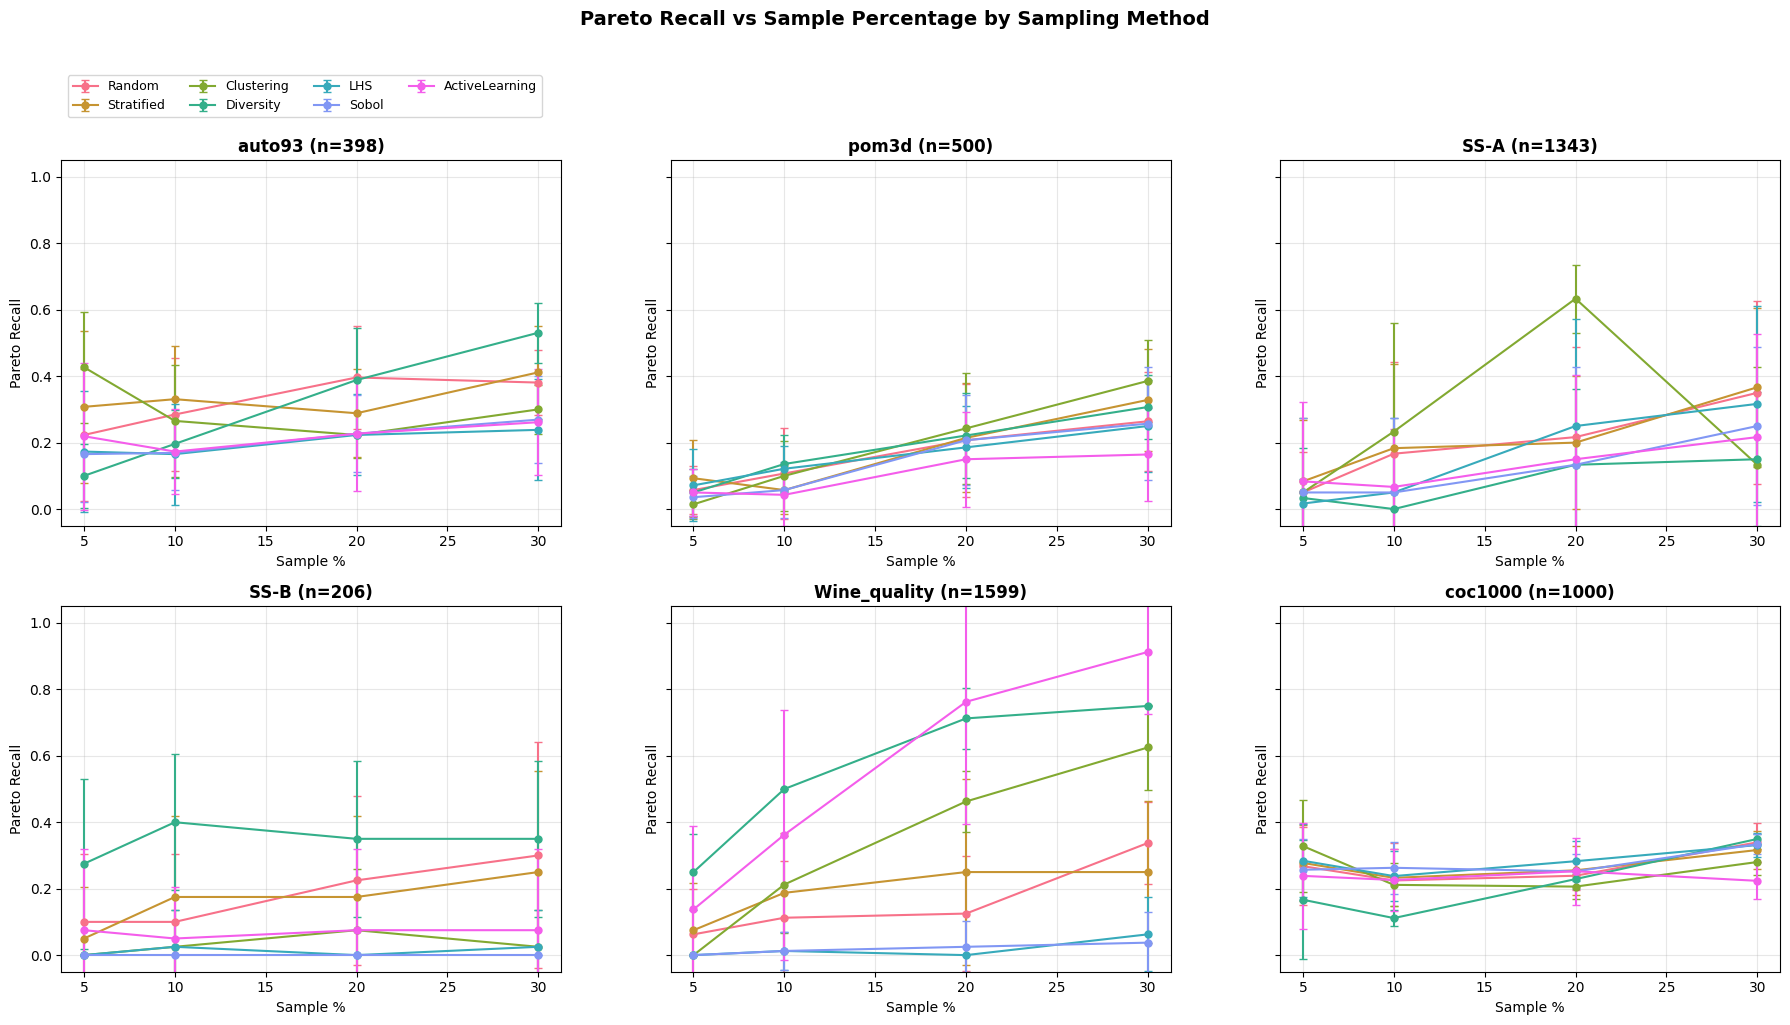

Saved: results_recall_vs_sample_pct.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

dataset_names = list(datasets.keys())
palette = sns.color_palette("husl", len(SAMPLING_METHODS))

for idx, ds_name in enumerate(dataset_names):
    ax = axes[idx]
    ds_data = results_df[results_df['dataset'] == ds_name]
    
    for midx, method_name in enumerate(SAMPLING_METHODS.keys()):
        method_data = ds_data[ds_data['method'] == method_name]
        grouped = method_data.groupby('sample_pct')['recall'].agg(['mean', 'std']).reset_index()
        
        ax.errorbar(grouped['sample_pct'], grouped['mean'], yerr=grouped['std'],
                    marker='o', capsize=3, label=method_name, color=palette[midx],
                    linewidth=1.5, markersize=5)
    
    ax.set_title(f"{ds_name} (n={len(datasets[ds_name]['df'])})", fontsize=12, fontweight='bold')
    ax.set_xlabel("Sample %")
    ax.set_ylabel("Pareto Recall")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, 1.25), loc='upper left', ncol=4, fontsize=9)
plt.suptitle("Pareto Recall vs Sample Percentage by Sampling Method", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_recall_vs_sample_pct.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_recall_vs_sample_pct.png")

## Section 9: IGD and Precision Plots (per Dataset)

Same layout but for **IGD** (lower is better) and **Precision**.

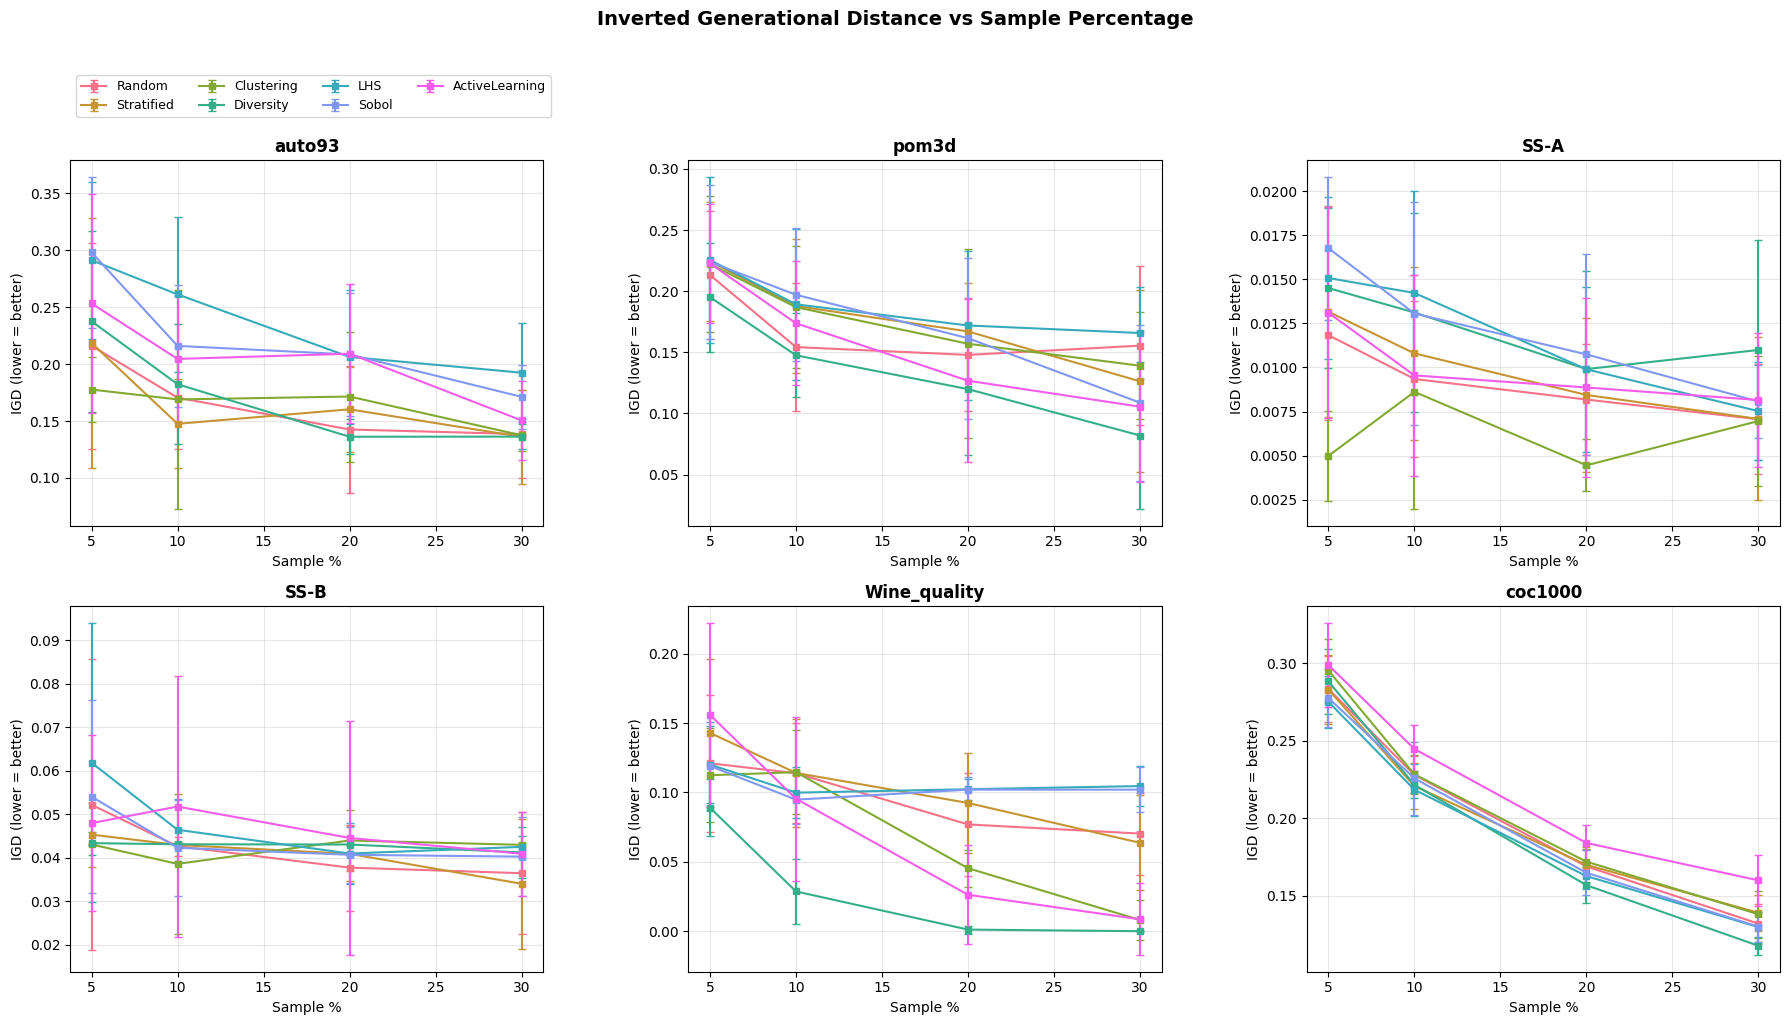

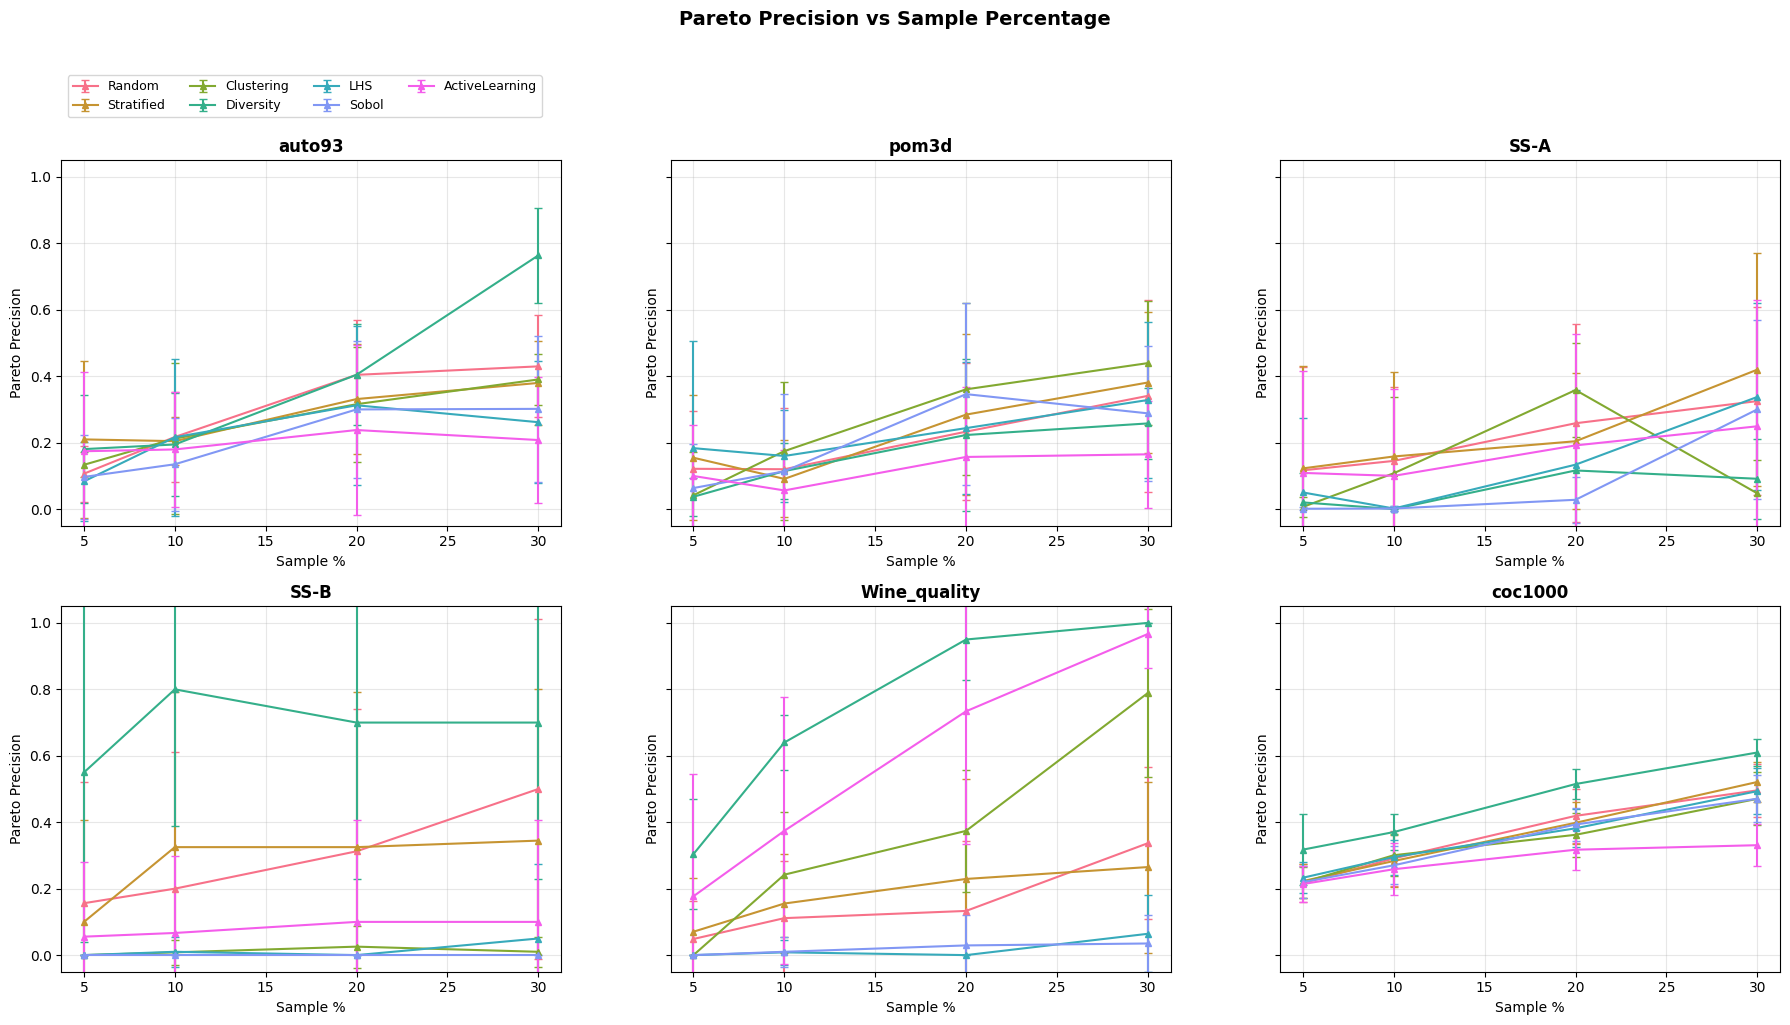

Saved: results_igd_vs_sample_pct.png, results_precision_vs_sample_pct.png


In [10]:
# --- IGD Plot ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for idx, ds_name in enumerate(dataset_names):
    ax = axes[idx]
    ds_data = results_df[results_df['dataset'] == ds_name]
    
    for midx, method_name in enumerate(SAMPLING_METHODS.keys()):
        method_data = ds_data[ds_data['method'] == method_name]
        grouped = method_data.groupby('sample_pct')['igd'].agg(['mean', 'std']).reset_index()
        
        ax.errorbar(grouped['sample_pct'], grouped['mean'], yerr=grouped['std'],
                    marker='s', capsize=3, label=method_name, color=palette[midx],
                    linewidth=1.5, markersize=5)
    
    ax.set_title(f"{ds_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Sample %")
    ax.set_ylabel("IGD (lower = better)")
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, 1.25), loc='upper left', ncol=4, fontsize=9)
plt.suptitle("Inverted Generational Distance vs Sample Percentage", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_igd_vs_sample_pct.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Precision Plot ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

for idx, ds_name in enumerate(dataset_names):
    ax = axes[idx]
    ds_data = results_df[results_df['dataset'] == ds_name]
    
    for midx, method_name in enumerate(SAMPLING_METHODS.keys()):
        method_data = ds_data[ds_data['method'] == method_name]
        grouped = method_data.groupby('sample_pct')['precision'].agg(['mean', 'std']).reset_index()
        
        ax.errorbar(grouped['sample_pct'], grouped['mean'], yerr=grouped['std'],
                    marker='^', capsize=3, label=method_name, color=palette[midx],
                    linewidth=1.5, markersize=5)
    
    ax.set_title(f"{ds_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Sample %")
    ax.set_ylabel("Pareto Precision")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, 1.25), loc='upper left', ncol=4, fontsize=9)
plt.suptitle("Pareto Precision vs Sample Percentage", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_precision_vs_sample_pct.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: results_igd_vs_sample_pct.png, results_precision_vs_sample_pct.png")

## Section 10: Heatmap — Method Comparison Across Datasets

Compare all methods side-by-side at each sample percentage using heatmaps of mean Recall and IGD.

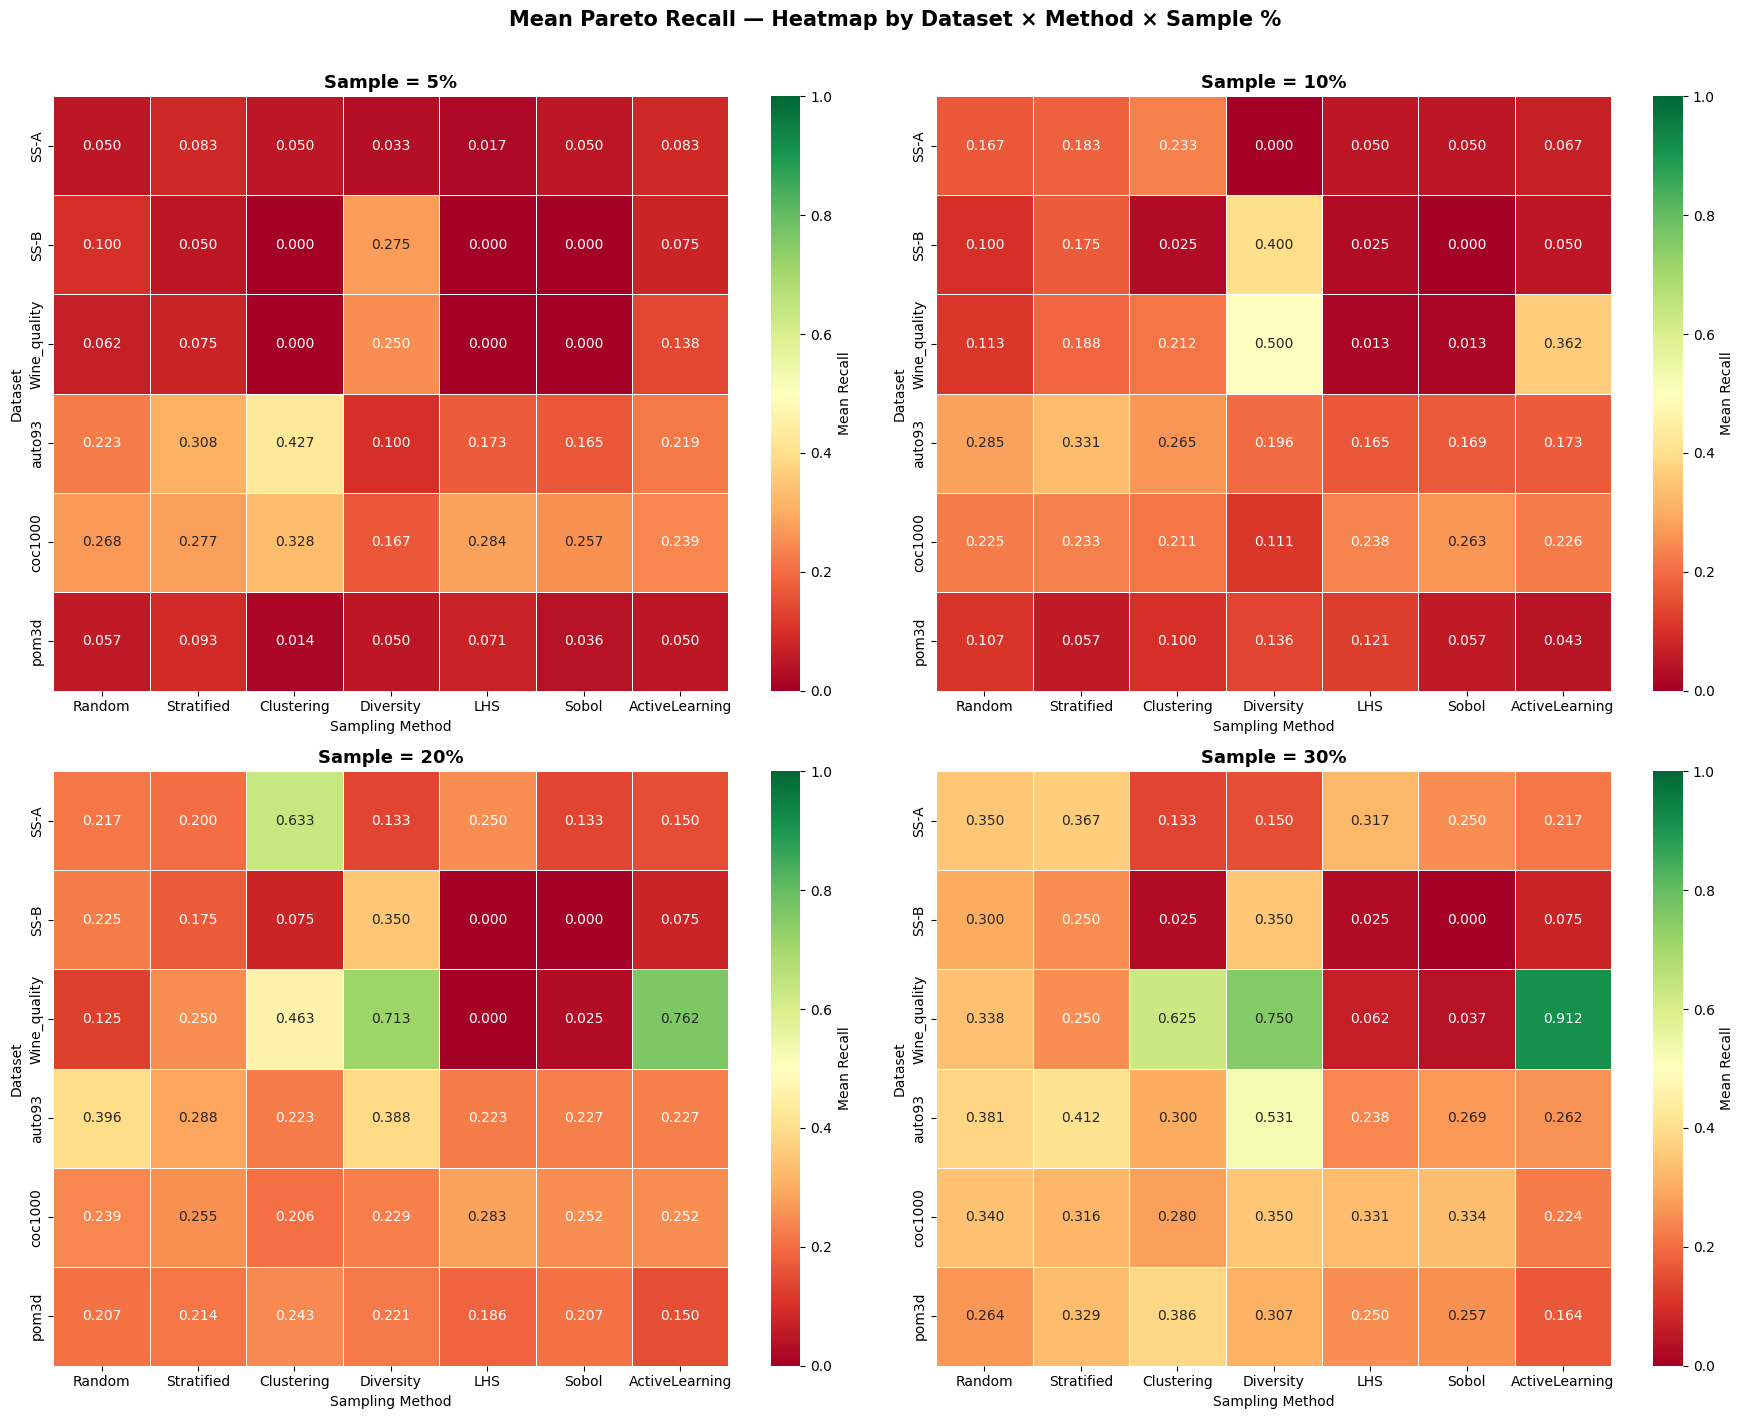

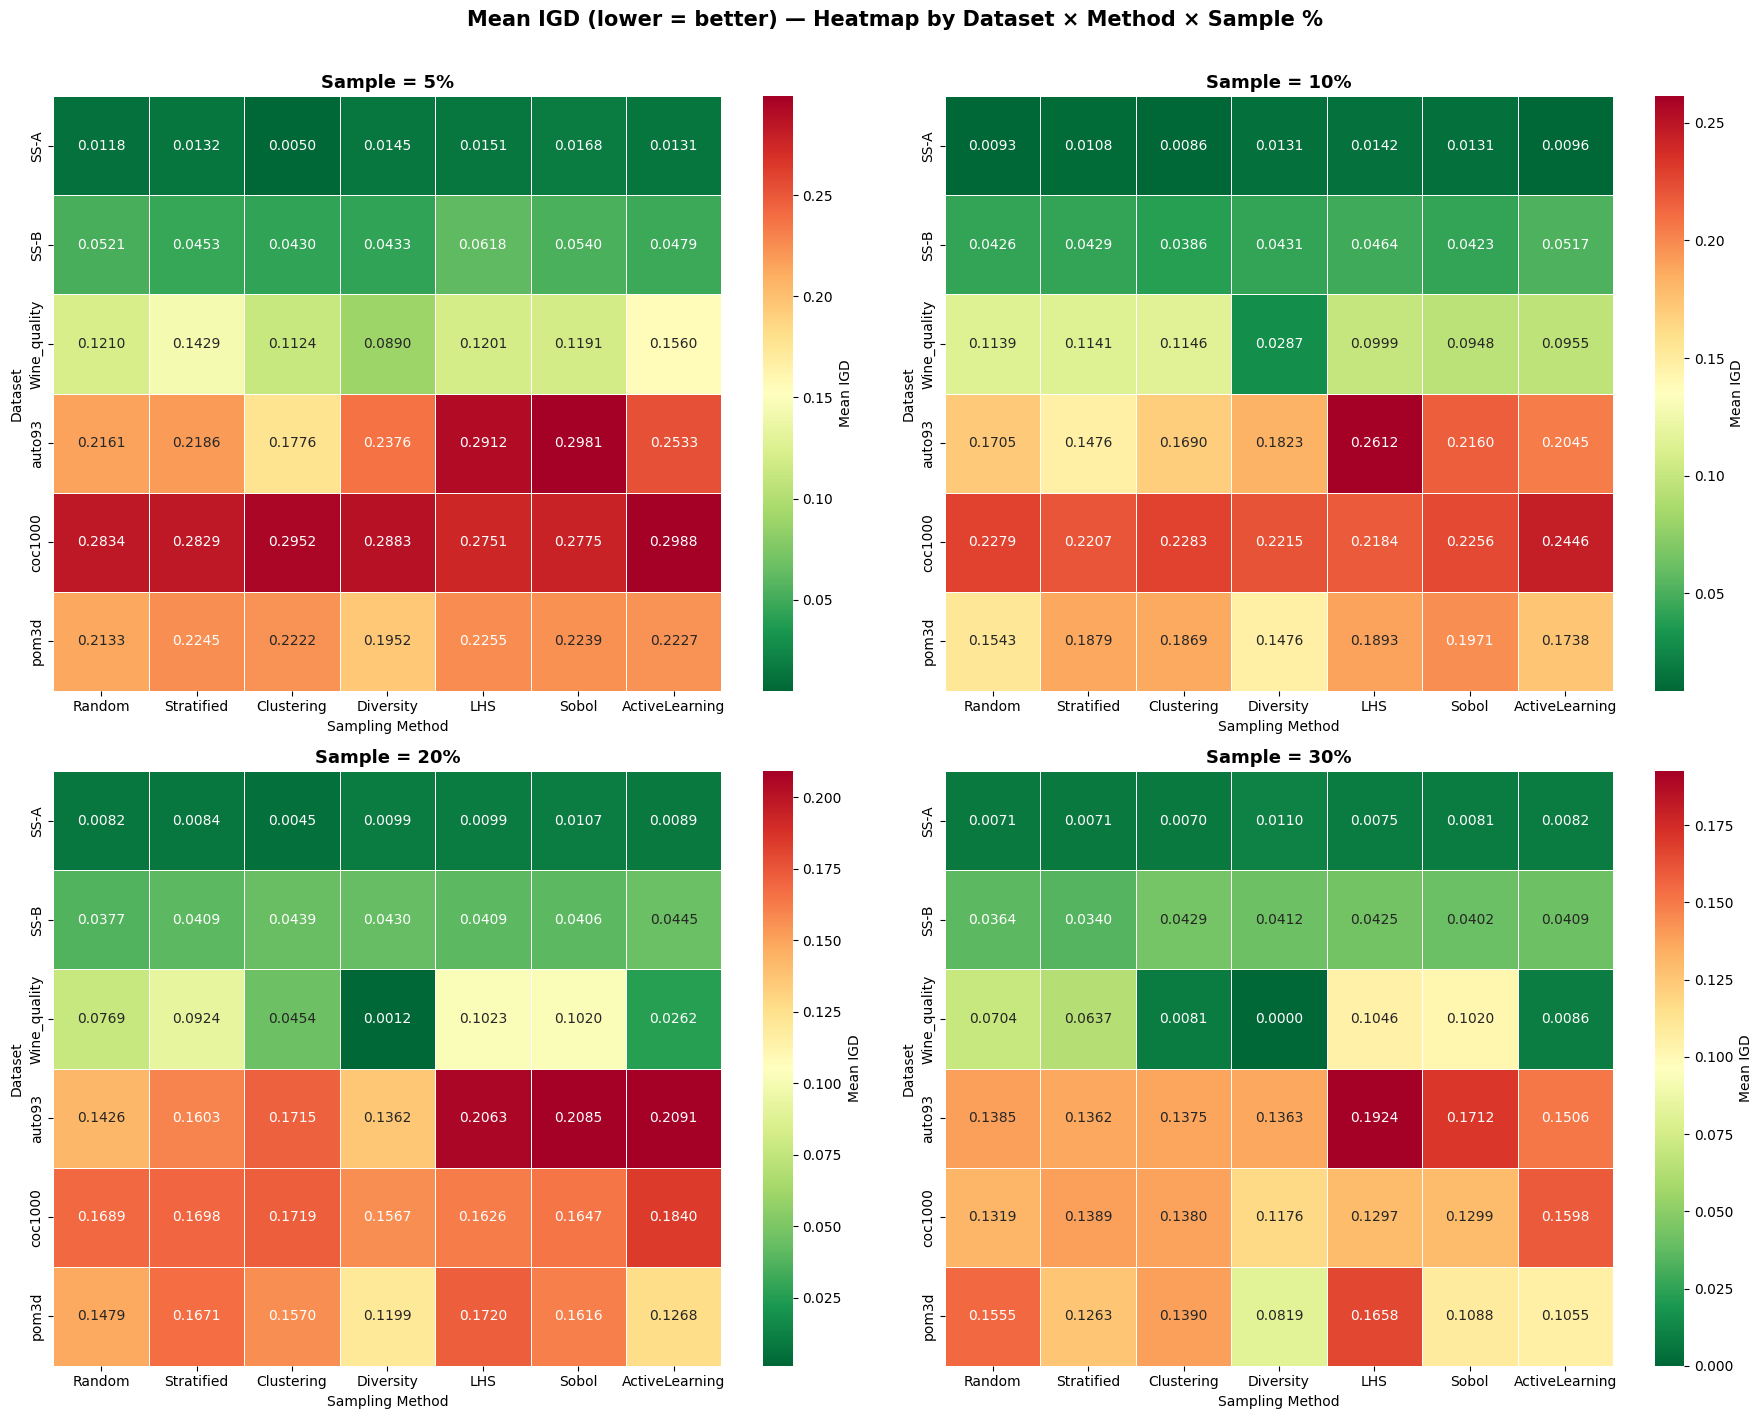

Saved: results_recall_heatmap.png, results_igd_heatmap.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for pct_idx, pct in enumerate(SAMPLE_PERCENTAGES):
    ax = axes[pct_idx // 2][pct_idx % 2]
    
    pct_data = results_df[results_df['sample_pct'] == pct]
    pivot = pct_data.groupby(['dataset', 'method'])['recall'].mean().unstack()
    pivot = pivot.reindex(columns=list(SAMPLING_METHODS.keys()))
    
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', vmin=0, vmax=1,
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Mean Recall'})
    ax.set_title(f"Sample = {pct}%", fontsize=13, fontweight='bold')
    ax.set_xlabel("Sampling Method")
    ax.set_ylabel("Dataset")

plt.suptitle("Mean Pareto Recall — Heatmap by Dataset × Method × Sample %",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("results_recall_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# --- IGD Heatmap ---
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for pct_idx, pct in enumerate(SAMPLE_PERCENTAGES):
    ax = axes[pct_idx // 2][pct_idx % 2]
    
    pct_data = results_df[results_df['sample_pct'] == pct]
    pivot = pct_data.groupby(['dataset', 'method'])['igd'].mean().unstack()
    pivot = pivot.reindex(columns=list(SAMPLING_METHODS.keys()))
    
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r', 
                ax=ax, linewidths=0.5, cbar_kws={'label': 'Mean IGD'})
    ax.set_title(f"Sample = {pct}%", fontsize=13, fontweight='bold')
    ax.set_xlabel("Sampling Method")
    ax.set_ylabel("Dataset")

plt.suptitle("Mean IGD (lower = better) — Heatmap by Dataset × Method × Sample %",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("results_igd_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: results_recall_heatmap.png, results_igd_heatmap.png")

## Section 11: Ranking Table — Best Method per Dataset

For each dataset and sample %, rank the methods by mean Recall and IGD. Highlight the winner.

In [12]:
# Best method by Recall (highest) and IGD (lowest) for each dataset × sample_pct
mean_results = results_df.groupby(['dataset', 'method', 'sample_pct']).agg(
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    precision_mean=('precision', 'mean'),
    igd_mean=('igd', 'mean'),
    hv_diff_mean=('hv_diff', 'mean'),
).reset_index()

# Best recall per (dataset, sample_pct)
best_recall = mean_results.loc[mean_results.groupby(['dataset', 'sample_pct'])['recall_mean'].idxmax()]
best_recall = best_recall[['dataset', 'sample_pct', 'method', 'recall_mean', 'recall_std']].copy()
best_recall.columns = ['Dataset', 'Sample%', 'Best Method (Recall)', 'Mean Recall', 'Std']
best_recall = best_recall.round(4)

print("=" * 80)
print("BEST SAMPLING METHOD BY PARETO RECALL (per dataset, per sample %)")
print("=" * 80)
print(best_recall.to_string(index=False))

# Best IGD per (dataset, sample_pct)
best_igd = mean_results.loc[mean_results.groupby(['dataset', 'sample_pct'])['igd_mean'].idxmin()]
best_igd = best_igd[['dataset', 'sample_pct', 'method', 'igd_mean']].copy()
best_igd.columns = ['Dataset', 'Sample%', 'Best Method (IGD)', 'Mean IGD']
best_igd = best_igd.round(4)

print("\n" + "=" * 80)
print("BEST SAMPLING METHOD BY IGD (per dataset, per sample %) — lower is better")
print("=" * 80)
print(best_igd.to_string(index=False))

BEST SAMPLING METHOD BY PARETO RECALL (per dataset, per sample %)
     Dataset  Sample% Best Method (Recall)  Mean Recall    Std
        SS-A        5       ActiveLearning       0.0833 0.2388
        SS-A       10           Clustering       0.2333 0.3262
        SS-A       20           Clustering       0.6333 0.1026
        SS-A       30           Stratified       0.3667 0.2394
        SS-B        5            Diversity       0.2750 0.2552
        SS-B       10            Diversity       0.4000 0.2052
        SS-B       20            Diversity       0.3500 0.2351
        SS-B       30            Diversity       0.3500 0.2351
Wine_quality        5            Diversity       0.2500 0.1147
Wine_quality       10            Diversity       0.5000 0.0000
Wine_quality       20       ActiveLearning       0.7625 0.3670
Wine_quality       30       ActiveLearning       0.9125 0.1863
      auto93        5           Clustering       0.4269 0.1664
      auto93       10           Stratified       0.3

## Section 12: Overall Method Ranking (Averaged Across All Datasets)

Which sampling method wins overall when averaged across all 6 datasets?

OVERALL METHOD PERFORMANCE (averaged across all datasets)
        method  sample_pct  recall_mean  recall_std  precision_mean  igd_mean  hv_diff_mean
    Stratified           5       0.1477      0.1892          0.1467    0.1546        0.0887
     Diversity           5       0.1458      0.1794          0.2349    0.1446        0.0709
    Clustering           5       0.1366      0.2149          0.0667    0.1426        0.0870
ActiveLearning           5       0.1339      0.2158          0.1382    0.1653        0.0909
        Random           5       0.1267      0.1701          0.1276    0.1496        0.0891
           LHS           5       0.0909      0.1453          0.0916    0.1648        0.0934
         Sobol           5       0.0847      0.1496          0.0635    0.1649        0.0856
     Diversity          10       0.2239      0.1991          0.3532    0.1060        0.0483
    Stratified          10       0.1944      0.1940          0.2029    0.1206        0.0592
    Clustering        

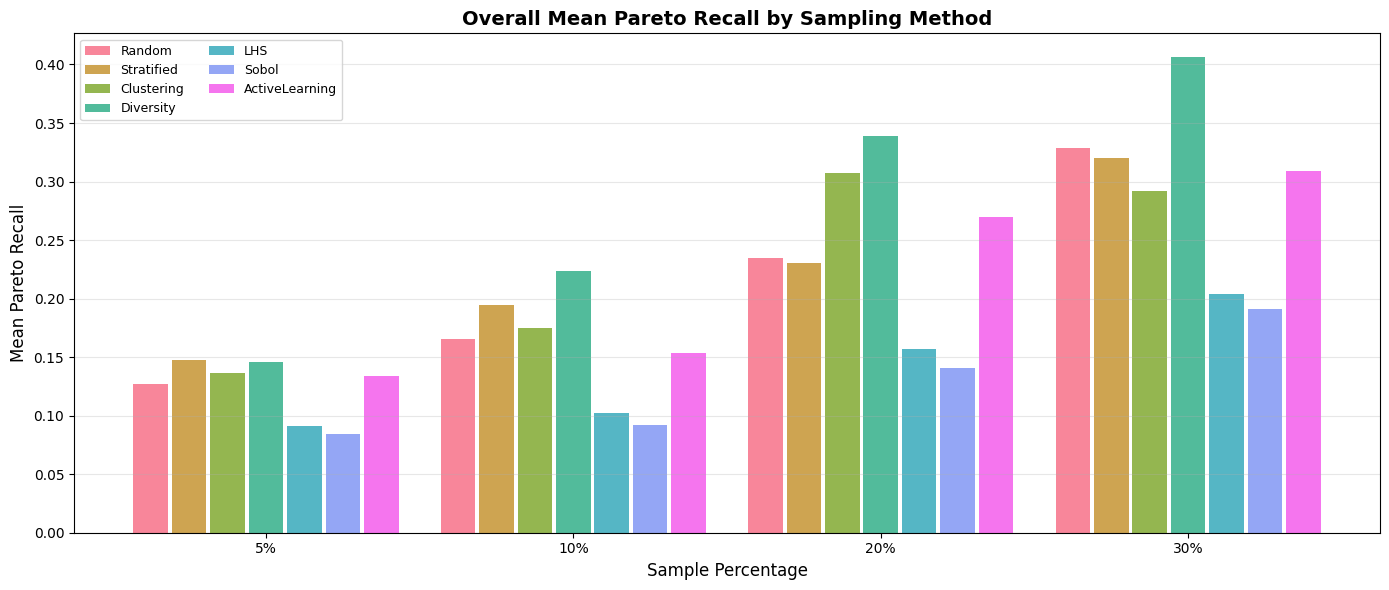

Saved: results_overall_recall_bars.png


In [13]:
# Overall ranking: average metrics across all datasets for each (method, sample_pct)
overall = results_df.groupby(['method', 'sample_pct']).agg(
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    precision_mean=('precision', 'mean'),
    igd_mean=('igd', 'mean'),
    hv_diff_mean=('hv_diff', 'mean'),
).reset_index().round(4)

print("=" * 90)
print("OVERALL METHOD PERFORMANCE (averaged across all datasets)")
print("=" * 90)
print(overall.sort_values(['sample_pct', 'recall_mean'], ascending=[True, False]).to_string(index=False))

# Bar chart: overall recall by method x sample_pct
fig, ax = plt.subplots(figsize=(14, 6))
x_labels = []
x_positions = []
bar_width = 0.1
methods_list = list(SAMPLING_METHODS.keys())

for pct_idx, pct in enumerate(SAMPLE_PERCENTAGES):
    pct_data = overall[overall['sample_pct'] == pct]
    for midx, method in enumerate(methods_list):
        row = pct_data[pct_data['method'] == method]
        if len(row) > 0:
            x = pct_idx * (len(methods_list) + 1) * bar_width + midx * bar_width
            ax.bar(x, row['recall_mean'].values[0], bar_width * 0.9,
                   color=palette[midx], label=method if pct_idx == 0 else None,
                   alpha=0.85)
    center = pct_idx * (len(methods_list) + 1) * bar_width + (len(methods_list) - 1) * bar_width / 2
    x_labels.append(f"{pct}%")
    x_positions.append(center)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels)
ax.set_xlabel("Sample Percentage", fontsize=12)
ax.set_ylabel("Mean Pareto Recall", fontsize=12)
ax.set_title("Overall Mean Pareto Recall by Sampling Method", fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=9, ncol=2)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("results_overall_recall_bars.png", dpi=150, bbox_inches='tight')
plt.show()

print("Saved: results_overall_recall_bars.png")

## Section 13: Hypervolume Difference Analysis

Hypervolume difference shows how close the predicted Pareto front's dominated volume is to the true front's. Lower = better.

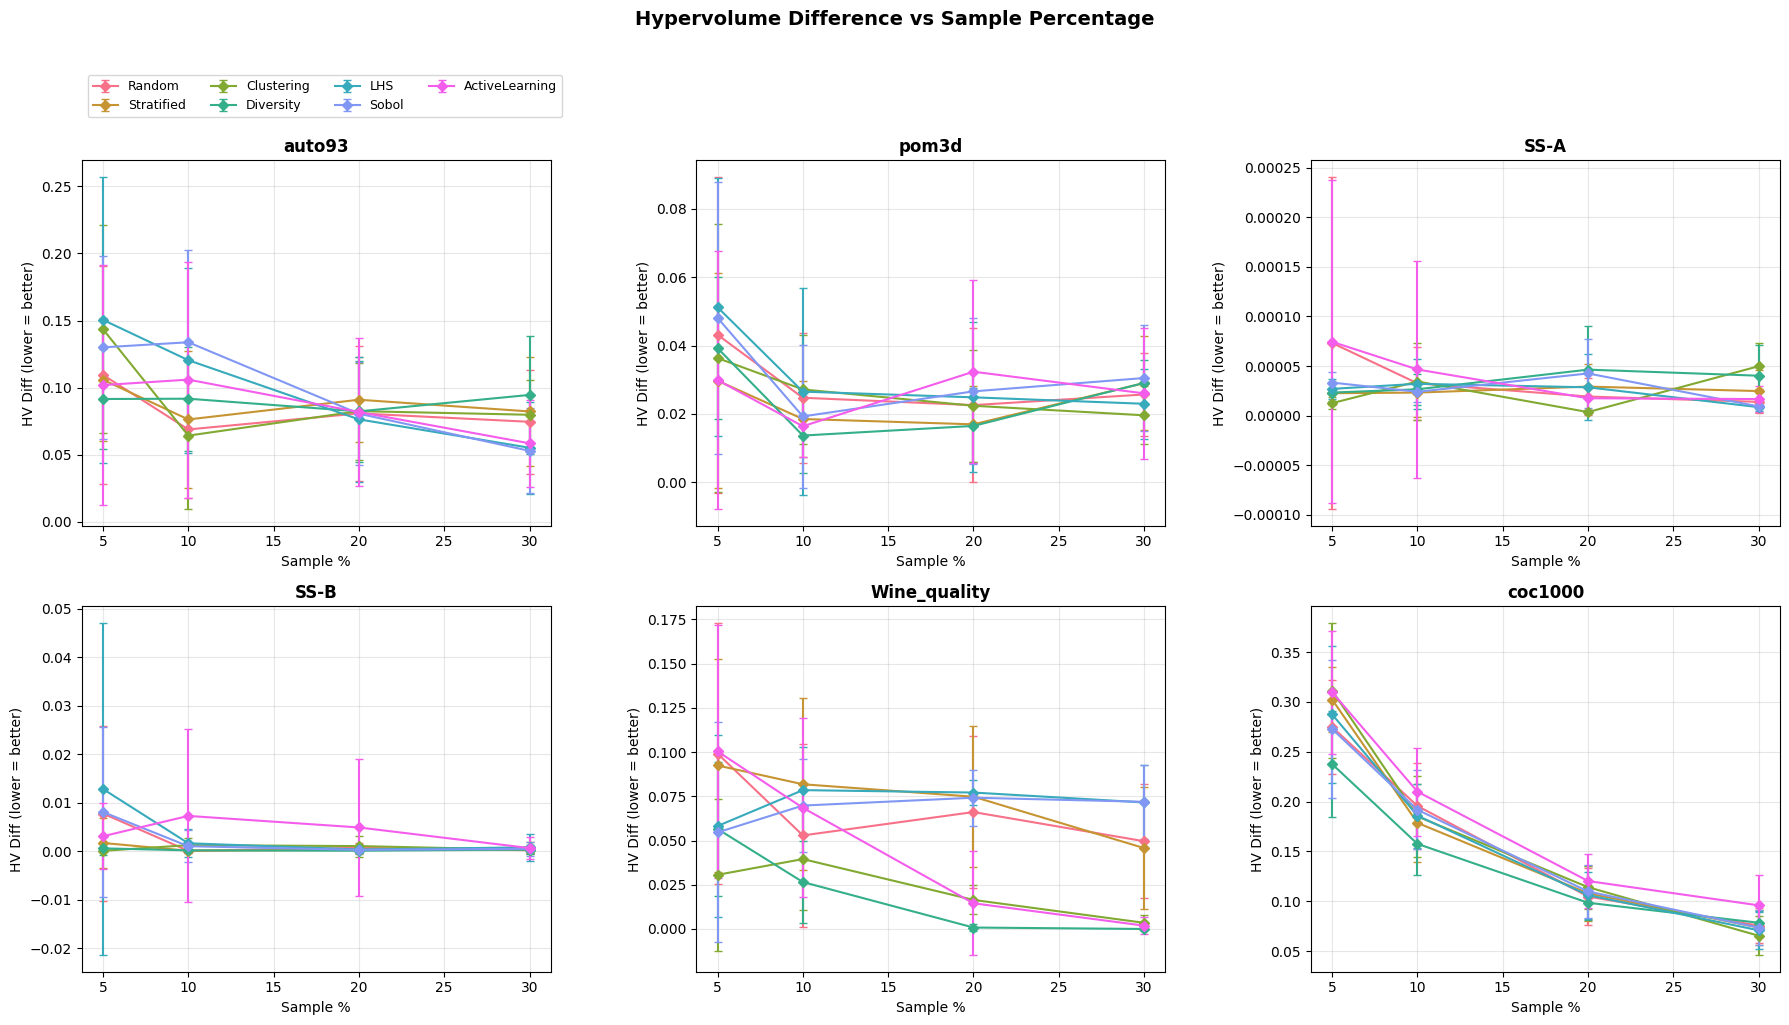

Saved: results_hv_diff_vs_sample_pct.png


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for idx, ds_name in enumerate(dataset_names):
    ax = axes[idx]
    ds_data = results_df[results_df['dataset'] == ds_name]
    
    for midx, method_name in enumerate(SAMPLING_METHODS.keys()):
        method_data = ds_data[ds_data['method'] == method_name]
        grouped = method_data.groupby('sample_pct')['hv_diff'].agg(['mean', 'std']).reset_index()
        
        ax.errorbar(grouped['sample_pct'], grouped['mean'], yerr=grouped['std'],
                    marker='D', capsize=3, label=method_name, color=palette[midx],
                    linewidth=1.5, markersize=5)
    
    ax.set_title(f"{ds_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Sample %")
    ax.set_ylabel("HV Diff (lower = better)")
    ax.grid(True, alpha=0.3)

axes[0].legend(bbox_to_anchor=(0, 1.25), loc='upper left', ncol=4, fontsize=9)
plt.suptitle("Hypervolume Difference vs Sample Percentage", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("results_hv_diff_vs_sample_pct.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results_hv_diff_vs_sample_pct.png")

## Section 14: Export Results & Summary

Save all raw results and aggregated statistics to CSV for further analysis.

In [16]:
# Save raw results
results_df.to_csv("experiment_raw_results.csv", index=False)
print(f"Saved raw results: experiment_raw_results.csv ({len(results_df)} rows)")

# Save aggregated stats
stats_df.to_csv("experiment_aggregated_stats.csv", index=False)
print(f"Saved aggregated stats: experiment_aggregated_stats.csv ({len(stats_df)} rows)")

# Save overall summary
overall.to_csv("experiment_overall_summary.csv", index=False)
print(f"Saved overall summary: experiment_overall_summary.csv")

# Print final summary
print("\n" + "=" * 90)
print("EXPERIMENT SUMMARY")
print("=" * 90)
print(f"Datasets tested:       {len(datasets)} ({', '.join(datasets.keys())})")
print(f"Sampling methods:      {len(SAMPLING_METHODS)} ({', '.join(SAMPLING_METHODS.keys())})")
print(f"Sample percentages:    {SAMPLE_PERCENTAGES}")
print(f"Repeats per config:    {N_REPEATS}")
print(f"Total experiments:     {len(results_df)}")
print(f"Total runtime:         {elapsed_total:.1f}s")

print("\n--- Key Findings ---")
# Best method overall at each sample %
for pct in SAMPLE_PERCENTAGES:
    pct_overall = overall[overall['sample_pct'] == pct]
    best = pct_overall.loc[pct_overall['recall_mean'].idxmax()]
    print(f"  At {pct:2d}% sample: Best = {best['method']:15s} (Recall={best['recall_mean']:.4f}, IGD={pct_overall.loc[pct_overall['igd_mean'].idxmin(), 'igd_mean']:.4f})")

Saved raw results: experiment_raw_results.csv (3360 rows)
Saved aggregated stats: experiment_aggregated_stats.csv (168 rows)
Saved overall summary: experiment_overall_summary.csv

EXPERIMENT SUMMARY
Datasets tested:       6 (auto93, pom3d, SS-A, SS-B, Wine_quality, coc1000)
Sampling methods:      7 (Random, Stratified, Clustering, Diversity, LHS, Sobol, ActiveLearning)
Sample percentages:    [5, 10, 20, 30]
Repeats per config:    20
Total experiments:     3360
Total runtime:         2930.6s

--- Key Findings ---
  At  5% sample: Best = Stratified      (Recall=0.1477, IGD=0.1426)
  At 10% sample: Best = Diversity       (Recall=0.2239, IGD=0.1060)
  At 20% sample: Best = Diversity       (Recall=0.3391, IGD=0.0778)
  At 30% sample: Best = Diversity       (Recall=0.4063, IGD=0.0647)


In [17]:
# ---- Detailed analysis for explanation ----

# 1) True Pareto front sizes
print("=" * 70)
print("TRUE PARETO FRONT SIZES (what we're trying to find)")
print("=" * 70)
for name, pf in true_pareto_fronts.items():
    total = len(datasets[name]['df'])
    print(f"  {name:15s}: {len(pf):4d} Pareto-optimal rows out of {total} total ({100*len(pf)/total:.1f}%)")

# 2) Overall method ranking at each sample %
print("\n" + "=" * 70)
print("OVERALL RESULTS (averaged across all 6 datasets, 20 repeats)")
print("=" * 70)
for pct in SAMPLE_PERCENTAGES:
    print(f"\n--- At {pct}% sampling budget ---")
    pct_data = overall[overall['sample_pct'] == pct].sort_values('recall_mean', ascending=False)
    for _, row in pct_data.iterrows():
        print(f"  {row['method']:15s} | Recall={row['recall_mean']:.3f} +/- {row['recall_std']:.3f} | "
              f"Precision={row['precision_mean']:.3f} | IGD={row['igd_mean']:.4f} | HV_Diff={row['hv_diff_mean']:.4f}")

# 3) Best per-dataset highlights
print("\n" + "=" * 70)
print("BEST RESULTS PER DATASET (at 30% sample)")
print("=" * 70)
pct30 = results_df[results_df['sample_pct'] == 30]
for ds in dataset_names:
    ds_data = pct30[pct30['dataset'] == ds]
    best_method = ds_data.groupby('method')['recall'].mean().idxmax()
    best_recall = ds_data.groupby('method')['recall'].mean().max()
    best_igd_method = ds_data.groupby('method')['igd'].mean().idxmin()
    best_igd_val = ds_data.groupby('method')['igd'].mean().min()
    n_objs = len(datasets[ds]['obj_cols'])
    pf_size = len(true_pareto_fronts[ds])
    print(f"  {ds:15s} ({n_objs} obj, PF={pf_size:3d}) | "
          f"Best Recall: {best_method:15s} = {best_recall:.3f} | "
          f"Best IGD: {best_igd_method:15s} = {best_igd_val:.4f}")

# 4) Does more sampling help? Show recall trend
print("\n" + "=" * 70)
print("DOES MORE SAMPLING HELP? (Diversity method recall across budgets)")
print("=" * 70)
div_data = results_df[results_df['method'] == 'Diversity']
for ds in dataset_names:
    ds_div = div_data[div_data['dataset'] == ds]
    recalls = ds_div.groupby('sample_pct')['recall'].mean()
    trend = " -> ".join([f"{pct}%: {recalls.get(pct, 0):.3f}" for pct in SAMPLE_PERCENTAGES])
    print(f"  {ds:15s}: {trend}")

# 5) Comparison: What if we just randomly picked 30% of rows - would we get PF members by chance?
print("\n" + "=" * 70)
print("SANITY CHECK: Expected PF recall if we just picked 30% rows randomly")
print("(without any model, pure chance of landing on PF members)")
print("=" * 70)
for ds in dataset_names:
    total = len(datasets[ds]['df'])
    pf_size = len(true_pareto_fronts[ds])
    expected_random_hits = 0.30 * pf_size  # 30% of PF members expected by chance
    expected_recall_no_model = 0.30  # random 30% of data includes ~30% of PF
    best_recall_30 = pct30[pct30['dataset'] == ds].groupby('method')['recall'].mean().max()
    improvement = best_recall_30 / expected_recall_no_model if expected_recall_no_model > 0 else 0
    print(f"  {ds:15s}: Chance baseline ~{expected_recall_no_model:.1%} | "
          f"Best model recall = {best_recall_30:.1%} | "
          f"Improvement = {improvement:.2f}x")

TRUE PARETO FRONT SIZES (what we're trying to find)
  auto93         :   13 Pareto-optimal rows out of 398 total (3.3%)
  pom3d          :    7 Pareto-optimal rows out of 500 total (1.4%)
  SS-A           :    3 Pareto-optimal rows out of 1343 total (0.2%)
  SS-B           :    2 Pareto-optimal rows out of 206 total (1.0%)
  Wine_quality   :    4 Pareto-optimal rows out of 1599 total (0.3%)
  coc1000        :  144 Pareto-optimal rows out of 1000 total (14.4%)

OVERALL RESULTS (averaged across all 6 datasets, 20 repeats)

--- At 5% sampling budget ---
  Stratified      | Recall=0.148 +/- 0.189 | Precision=0.147 | IGD=0.1546 | HV_Diff=0.0887
  Diversity       | Recall=0.146 +/- 0.179 | Precision=0.235 | IGD=0.1446 | HV_Diff=0.0709
  Clustering      | Recall=0.137 +/- 0.215 | Precision=0.067 | IGD=0.1426 | HV_Diff=0.0870
  ActiveLearning  | Recall=0.134 +/- 0.216 | Precision=0.138 | IGD=0.1653 | HV_Diff=0.0909
  Random          | Recall=0.127 +/- 0.170 | Precision=0.128 | IGD=0.1496 | HV_

In [18]:
# Part A: Pareto front sizes and baseline
for name, pf in true_pareto_fronts.items():
    total = len(datasets[name]['df'])
    print(f"{name:15s}: PF={len(pf):3d}/{total} ({100*len(pf)/total:.1f}%)")

auto93         : PF= 13/398 (3.3%)
pom3d          : PF=  7/500 (1.4%)
SS-A           : PF=  3/1343 (0.2%)
SS-B           : PF=  2/206 (1.0%)
Wine_quality   : PF=  4/1599 (0.3%)
coc1000        : PF=144/1000 (14.4%)


In [19]:
# Part B: Best results at 30% and improvement over random baseline
pct30 = results_df[results_df['sample_pct'] == 30]
for ds in dataset_names:
    ds_data = pct30[pct30['dataset'] == ds]
    best_method = ds_data.groupby('method')['recall'].mean().idxmax()
    best_recall = ds_data.groupby('method')['recall'].mean().max()
    best_igd_method = ds_data.groupby('method')['igd'].mean().idxmin()
    best_igd_val = ds_data.groupby('method')['igd'].mean().min()
    improvement = best_recall / 0.30
    print(f"{ds:15s} | Best Recall: {best_method:15s}={best_recall:.3f} ({improvement:.2f}x vs random baseline 0.30) | Best IGD: {best_igd_method}={best_igd_val:.4f}")

auto93          | Best Recall: Diversity      =0.531 (1.77x vs random baseline 0.30) | Best IGD: Stratified=0.1362
pom3d           | Best Recall: Clustering     =0.386 (1.29x vs random baseline 0.30) | Best IGD: Diversity=0.0819
SS-A            | Best Recall: Stratified     =0.367 (1.22x vs random baseline 0.30) | Best IGD: Clustering=0.0070
SS-B            | Best Recall: Diversity      =0.350 (1.17x vs random baseline 0.30) | Best IGD: Stratified=0.0340
Wine_quality    | Best Recall: ActiveLearning =0.912 (3.04x vs random baseline 0.30) | Best IGD: Diversity=0.0000
coc1000         | Best Recall: Diversity      =0.350 (1.17x vs random baseline 0.30) | Best IGD: Diversity=0.1176


In [20]:
# Part C: Diversity recall trend across budgets
print("Diversity sampling recall trend (5% -> 10% -> 20% -> 30%):")
div_data = results_df[results_df['method'] == 'Diversity']
for ds in dataset_names:
    ds_div = div_data[div_data['dataset'] == ds]
    recalls = ds_div.groupby('sample_pct')['recall'].mean()
    trend = " -> ".join([f"{pct}%:{recalls.get(pct, 0):.3f}" for pct in SAMPLE_PERCENTAGES])
    print(f"  {ds:15s}: {trend}")

print("\nOverall winner at each budget:")
for pct in SAMPLE_PERCENTAGES:
    pct_all = overall[overall['sample_pct'] == pct]
    best = pct_all.loc[pct_all['recall_mean'].idxmax()]
    print(f"  {pct:2d}%: {best['method']:15s} Recall={best['recall_mean']:.3f}, IGD={pct_all.loc[pct_all['igd_mean'].idxmin(),'igd_mean']:.4f}")

Diversity sampling recall trend (5% -> 10% -> 20% -> 30%):
  auto93         : 5%:0.100 -> 10%:0.196 -> 20%:0.388 -> 30%:0.531
  pom3d          : 5%:0.050 -> 10%:0.136 -> 20%:0.221 -> 30%:0.307
  SS-A           : 5%:0.033 -> 10%:0.000 -> 20%:0.133 -> 30%:0.150
  SS-B           : 5%:0.275 -> 10%:0.400 -> 20%:0.350 -> 30%:0.350
  Wine_quality   : 5%:0.250 -> 10%:0.500 -> 20%:0.713 -> 30%:0.750
  coc1000        : 5%:0.167 -> 10%:0.111 -> 20%:0.229 -> 30%:0.350

Overall winner at each budget:
   5%: Stratified      Recall=0.148, IGD=0.1426
  10%: Diversity       Recall=0.224, IGD=0.1060
  20%: Diversity       Recall=0.339, IGD=0.0778
  30%: Diversity       Recall=0.406, IGD=0.0647


In [21]:
# Part D: Compare smart vs random sampling (key question: does smart sampling help?)
print("=== SMART SAMPLING vs RANDOM SAMPLING (Recall) ===\n")
for pct in SAMPLE_PERCENTAGES:
    pct_data = stats_df[stats_df['sample_pct'] == pct]
    random_avg = pct_data[pct_data['method'] == 'Random']['recall_mean'].mean()
    best_method_data = overall[(overall['sample_pct'] == pct)]
    best_row = best_method_data.loc[best_method_data['recall_mean'].idxmax()]
    print(f"  {pct:2d}% budget: Random={random_avg:.3f}, Best({best_row['method']})={best_row['recall_mean']:.3f}, Gain={best_row['recall_mean']/max(random_avg,0.001):.2f}x")

print("\n=== IGD COMPARISON (lower = better) ===\n")
for pct in SAMPLE_PERCENTAGES:
    pct_data = stats_df[stats_df['sample_pct'] == pct]
    random_igd = pct_data[pct_data['method'] == 'Random']['igd_mean'].mean()
    best_igd_data = overall[(overall['sample_pct'] == pct)]
    best_igd_row = best_igd_data.loc[best_igd_data['igd_mean'].idxmin()]
    improvement = (random_igd - best_igd_row['igd_mean']) / max(random_igd, 0.001) * 100
    print(f"  {pct:2d}% budget: Random IGD={random_igd:.4f}, Best({best_igd_row['method']}) IGD={best_igd_row['igd_mean']:.4f}, {improvement:.1f}% better")

print("\n=== METHOD RANKING (by mean recall across all datasets & budgets) ===\n")
method_rank = results_df.groupby('method')['recall'].mean().sort_values(ascending=False)
for i, (m, r) in enumerate(method_rank.items(), 1):
    print(f"  {i}. {m:20s} Recall={r:.3f}")

=== SMART SAMPLING vs RANDOM SAMPLING (Recall) ===

   5% budget: Random=0.127, Best(Stratified)=0.148, Gain=1.17x
  10% budget: Random=0.166, Best(Diversity)=0.224, Gain=1.35x
  20% budget: Random=0.235, Best(Diversity)=0.339, Gain=1.44x
  30% budget: Random=0.329, Best(Diversity)=0.406, Gain=1.24x

=== IGD COMPARISON (lower = better) ===

   5% budget: Random IGD=0.1496, Best(Clustering) IGD=0.1426, 4.7% better
  10% budget: Random IGD=0.1198, Best(Diversity) IGD=0.1060, 11.5% better
  20% budget: Random IGD=0.0970, Best(Diversity) IGD=0.0778, 19.8% better
  30% budget: Random IGD=0.0900, Best(Diversity) IGD=0.0647, 28.1% better

=== METHOD RANKING (by mean recall across all datasets & budgets) ===

  1. Diversity            Recall=0.279
  2. Clustering           Recall=0.227
  3. Stratified           Recall=0.223
  4. ActiveLearning       Recall=0.216
  5. Random               Recall=0.214
  6. LHS                  Recall=0.138
  7. Sobol                Recall=0.127
